# Transformation to C Code (Simple)

## Imports

In [1]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import os
import numpy as np

from zoomy_core.model.models.shallow_water import ShallowWaterEquations as SWE
from zoomy_core.model.models.shallow_water_topo import NumericalShallowWaterEquationsWithTopo as SWEB

import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
from zoomy_core.misc.misc import Zstruct, Settings
from zoomy_core.transformation.to_c import CppModel, CppNumerics
import zoomy_core.misc.misc as misc


## Model definition

In [2]:
bcs = BC.BoundaryConditions(
    [
        BC.Wall(tag="wall"),
        BC.Wall(tag="inflow"),
        BC.Wall(tag="outflow"),
    ]
)

def custom_ic(x):
    Q = np.zeros(4, dtype=float)
    Q[1] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

model = SWEB(
    dimension=2,
    boundary_conditions=bcs,
    initial_conditions=ic,
    aux_variables=1,
)


## Sympy Model

In [3]:
import sympy as sp

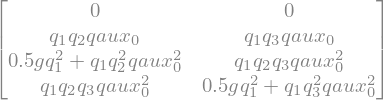

In [4]:
model.flux()

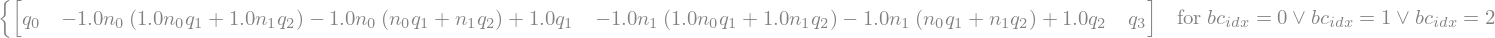

In [5]:
model.print_boundary_conditions()

## Code transformation

In [6]:
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/trafo", filename="swe.h5", clean_directory=True, snapshots=2))
CppModel.write_code(model, settings)


'/home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Model.H'

In [7]:
! cp /home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Model.H /home/ingo/Git/Zoomy/library/zoomy_dmplex

In [8]:
from zoomy_core.fvm.symbolic_numerics import PositiveRusanov, Rusanov

In [9]:
# numerics = PositiveRusanov(model)
numerics = Rusanov(model)

In [10]:
numerics.numerical_flux()

TypeError: Numerics.local_max_abs_eigenvalue() takes 1 positional argument but 4 were given

In [ ]:
CppNumerics.write_code(numerics, settings)

TypeError: Numerics.update_q() takes 1 positional argument but 3 were given

In [ ]:
! cp /home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Numerics.H /home/ingo/Git/Zoomy/library/zoomy_dmplex


## Check the output

In [ ]:
main_dir = misc.get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.c_interface/Model.H'))
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <algorithm>
#include <vector>
#include <string>
#include <algorithm>

template <typename T>
struct Model {
    // --- Constants ---
    static constexpr int n_dof_q    = 4;
    static constexpr int n_dof_qaux = 1;
    static constexpr int dimension  = 2;
    static constexpr int n_boundary_tags = 3;

    // --- Helpers ---
    static const std::vector<std::string> get_boundary_tags() { return { "inflow", "outflow", "wall" }; }

    // --- Kernels ---

    static inline void flux(
        const T* Q,
        const T* Qaux,
        T* res)
    {
    T t0 = Q[1]*Qaux[0];
    T t1 = 0.5*9.81*std::pow(Q[1], 2);
    T t2 = Q[1]*std::pow(Qaux[0], 2);
    T t3 = Q[2]*Q[3]*t2;
    res[0] = 0;
    res[1] = 0;
    res[2] = Q[2]*t0;
    res[3] = Q[3]*t0;
    res[4] = std::pow(Q[2], 2)*t2 + t1;
    res[5] = t3;
    res[6] = t3;
    res[7] = std::pow(Q[3], 2)*t2 + t1;
    }


    static inline void dflux(
        const T* Q,
        const T* Qaux,
        T* re

In [ ]:
main_dir = misc.get_main_directory()
path = os.path.join(
    main_dir, os.path.join(settings.output.directory, ".c_interface/Numerics.H")
)
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <algorithm>
#include <vector>

#define PORTABLE_FN
template <typename T>
struct Numerics {

    // --- Numerics Constants ---
    static constexpr int n_dof_q = 4;

    // --- Kernels ---

    PORTABLE_FN static inline void numerical_flux(
        const T* Q_minus,
        const T* Q_plus,
        const T* Qaux_minus,
        const T* Qaux_plus,
        const T* n,
        T* res)
    {
    T t0 = Q_minus[1] > 1e-06;
    T t1 = Q_plus[1] > 1e-06;
    T t2 = std::pow(Qaux_minus[0], 2);
    T t3 = Q_minus[1]*t2;
    T t4 = 1.0*t3;
    T t5 = Q_minus[2]*n[0];
    T t6 = Q_minus[3]*n[1];
    T t7 = t4*t5 + t4*t6;
    T t8 = std::pow(Qaux_plus[0], 2);
    T t9 = Q_plus[1]*t8;
    T t10 = 1.0*t9;
    T t11 = Q_plus[2]*n[0];
    T t12 = Q_plus[3]*n[1];
    T t13 = t10*t11 + t10*t12;
    T t14 = t5*t6;
    T t15 = std::pow(n[0], 2);
    T t16 = std::pow(Q_minus[1], 2);
    T t17 = 0.5*9.81;
    T t18 = t16*t17;
    T t19 = Qaux_minus[0]*t18;
    T t20 = s

In [ ]:
main_dir = misc.get_main_directory()
path = os.path.join(
    main_dir, os.path.join(main_dir, "library/zoomy_dmplex/Numerics.H")
)
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <algorithm>
#include <vector>

#define PORTABLE_FN
template <typename T>
struct Numerics {

    // --- Numerics Constants ---
    static constexpr int n_dof_q = 4;

    // --- Kernels ---

    PORTABLE_FN static inline void numerical_flux(
        const T* Q_minus,
        const T* Q_plus,
        const T* Qaux_minus,
        const T* Qaux_plus,
        const T* n,
        T* res)
    {
    T t0 = Q_minus[1] > 1e-06;
    T t1 = Q_plus[1] > 1e-06;
    T t2 = std::pow(Qaux_minus[0], 2);
    T t3 = Q_minus[1]*t2;
    T t4 = 1.0*t3;
    T t5 = Q_minus[2]*n[0];
    T t6 = Q_minus[3]*n[1];
    T t7 = t4*t5 + t4*t6;
    T t8 = std::pow(Qaux_plus[0], 2);
    T t9 = Q_plus[1]*t8;
    T t10 = 1.0*t9;
    T t11 = Q_plus[2]*n[0];
    T t12 = Q_plus[3]*n[1];
    T t13 = t10*t11 + t10*t12;
    T t14 = t5*t6;
    T t15 = std::pow(n[0], 2);
    T t16 = std::pow(Q_minus[1], 2);
    T t17 = 0.5*9.81;
    T t18 = t16*t17;
    T t19 = Qaux_minus[0]*t18;
    T t20 = s